In [5]:
import joblib
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [3]:
pca = joblib.load("../data/hlca_50pc.joblib")

In [4]:
pca.explained_variance_

array([164.31301648,  89.03990392,  52.05149034,  45.74626821,
        31.7640504 ,  24.25921896,  23.75375735,  19.68336169,
        17.44279717,  15.95933433,  13.19074517,  10.93181231,
         9.60545688,   8.51535717,   7.65570908,   7.1546618 ,
         6.21597192,   5.70073162,   5.13933872,   5.04272423,
         4.82442574,   4.42412279,   4.26712811,   3.96835847,
         3.81702294,   3.63651193,   3.47798079,   3.39451736,
         3.15008242,   3.05035336,   2.89307773,   2.82495794,
         2.76453605,   2.7155663 ,   2.61396156,   2.56732241,
         2.50652293,   2.40818054,   2.38379279,   2.34107865,
         2.25067218,   2.07358298,   2.03697937,   1.93997449,
         1.89648058,   1.88065968,   1.81548019,   1.72566474,
         1.65443387,   1.54064409])

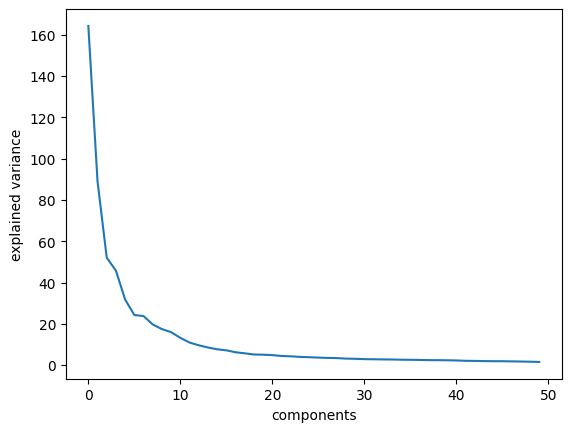

In [7]:
plt.plot(pca.explained_variance_)
plt.xlabel("components")
plt.ylabel("explained variance")
plt.show()

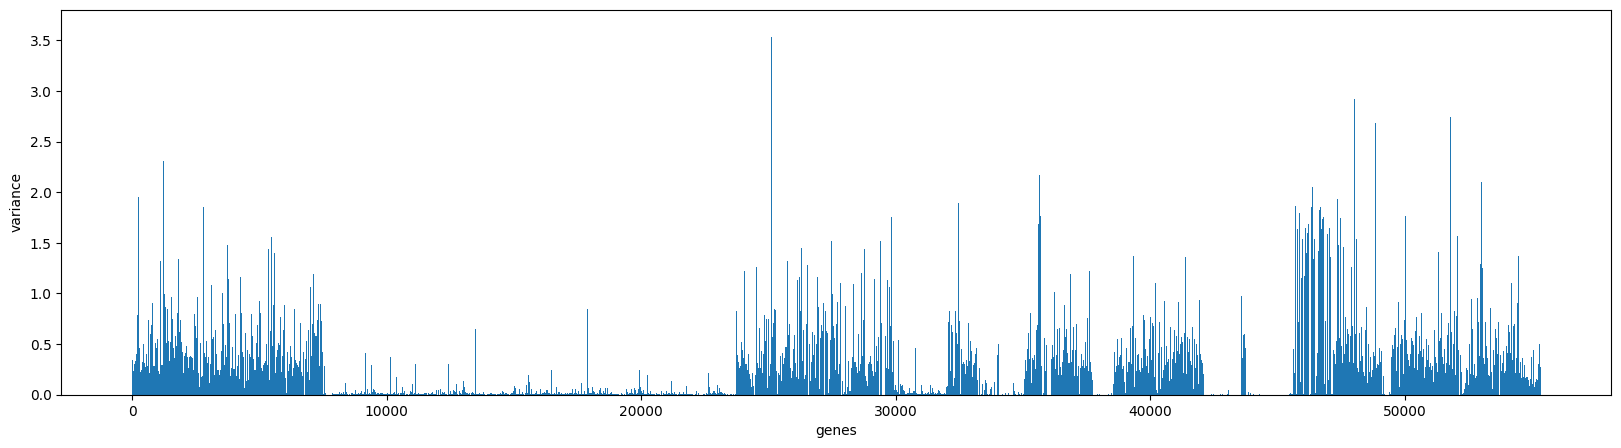

In [39]:
plt.figure(figsize=(20, 5))
plt.bar(range(len(pca.var_)), pca.var_, width=25)
plt.xlabel("genes")
plt.ylabel("variance")
plt.show()

In [15]:
pca.components_

array([[ 2.48049365e-03, -3.47243536e-05, -4.04346224e-05, ...,
        -3.42663213e-03, -3.88723910e-03, -1.03869257e-03],
       [ 2.81358994e-03,  2.42310095e-05,  1.62137192e-05, ...,
        -3.07654342e-03,  4.57542015e-03, -2.30080221e-03],
       [-1.80166615e-03,  3.64489873e-04,  1.79581680e-05, ...,
         4.58261992e-03,  2.58122413e-03,  4.50911708e-03],
       ...,
       [ 3.33336091e-03, -4.01118325e-04, -7.14653451e-05, ...,
         1.74214101e-04, -2.30042610e-03, -2.88763576e-03],
       [-3.54492161e-03, -6.28351622e-04, -8.73787804e-06, ...,
         2.02127016e-03,  3.09104086e-03, -4.57947043e-03],
       [ 1.14532029e-03,  6.21342892e-04,  3.45183938e-05, ...,
         3.16571831e-03,  2.99830787e-03, -1.82909067e-03]],
      shape=(50, 55329))

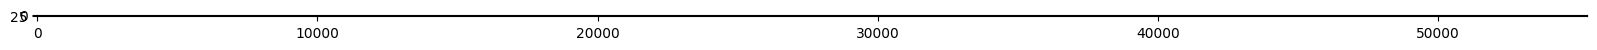

In [17]:
plt.figure(figsize=(20, 5))
plt.imshow(pca.components_, cmap="viridis")
plt.show()

In [40]:
import pandas as pd
import numpy as np

# 1. Standardize your huge matrix (50 samples, 50000 features)
# 'X' is your raw numpy array or pandas dataframe

# 2. Fit PCA using the optimized 'randomized' solver for wide data
# We cap n_components at 5 since you only have 50 samples

# 3. Create the Loadings Matrix
# Mathematically: loadings = components * sqrt(eigenvalues)
loadings_matrix = pca.components_.T 

# 4. Convert to a readable DataFrame
# If X was a DataFrame, use X.columns. Otherwise, use a generated list.
feature_names = [f"Gene_{i}" for i in range(len(pca.var_))]

loadings = pd.DataFrame(
    loadings_matrix,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=feature_names
)


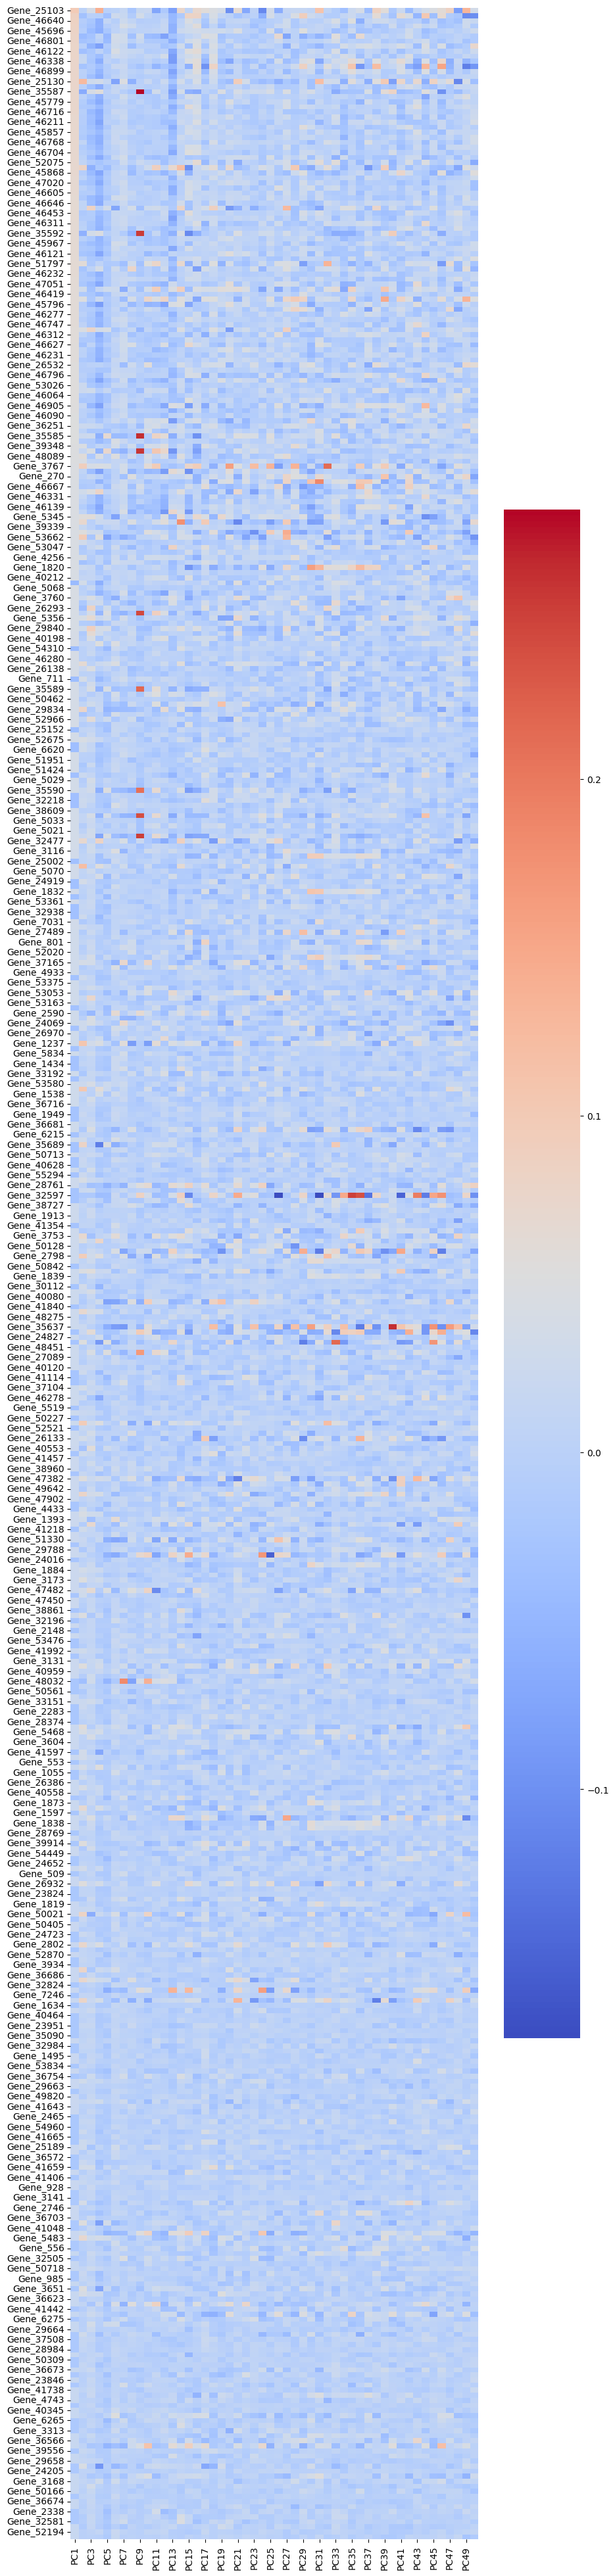

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Assume 'loadings' is your DataFrame from the PCA step (Size: 50000 features x 5 PCs)
# For this example, let's look at the features with the highest absolute weight on PC1
top_pc1_features = loadings['PC1'].abs().nlargest(500).index

# 2. Filter your loading matrix to just these top 30 impactful features
filtered_loadings = loadings.loc[top_pc1_features]

# 3. Plot a highly readable heatmap
plt.figure(figsize=(10, 50))
sns.heatmap(filtered_loadings, cmap='coolwarm', annot=False, fmt=".2f")
plt.show()
